In [1]:
!pip install captum torchvision seaborn matplotlib pandas tqdm pyarrow


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 71.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 119.5 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
shap 0.50.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
pytensor 2.37.0 requires numpy>=2.

In [1]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


In [2]:
import os, gc, glob, torch, numpy as np, pandas as pd
from PIL import Image
from io import BytesIO
from tqdm import tqdm
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import torchvision.models as models
import torchvision.transforms as transforms
import torchvision.transforms.functional as TF
from captum.attr import IntegratedGradients, GradientShap, LayerGradCam, Lime
import matplotlib.pyplot as plt
import seaborn as sns
from skimage.segmentation import quickshift

In [3]:
# Device Config
SEED = 42
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
np.random.seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

In [4]:
# Directory Definition
PARQUET_PATH = "/content/drive/MyDrive/xai-stability-benchmark/datasets/imagenet_sample.parquet"
RESULT_DIR = "/content/drive/MyDrive/xai-stability-benchmark/results_imagenet"

os.makedirs(RESULT_DIR, exist_ok=True)
print(DEVICE)


cuda


In [5]:
PERTURBATION_TYPE = "rotation"
# Options: "rotation", "brightness", "noise", "translation", "jpeg"

In [6]:
# FASS Depends on 3 measures: 1) Spearman Score 2) SSIM 3) Top-K-Jaccard Similarity

# SSIM
def get_ssim_spatial(attr1, attr2):
    def norm(x): return (x - x.min()) / (x.max() - x.min() + 1e-8)
    a1, a2 = norm(attr1), norm(attr2)
    pool = nn.AvgPool2d(11, stride=1, padding=5)
    mu1, mu2 = pool(a1), pool(a2)
    sigma12 = pool(a1 * a2) - mu1 * mu2
    sigma1_sq = pool(a1 * a1) - mu1 * mu1
    sigma2_sq = pool(a2 * a2) - mu2 * mu2
    c1, c2 = 0.01**2, 0.03**2
    ssim_map = ((2 * mu1 * mu2 + c1) * (2 * sigma12 + c2)) / ((mu1**2 + mu2**2 + c1) * (sigma1_sq + sigma2_sq + c2))
    return ssim_map.view(attr1.shape[0], -1).mean(dim=1)

# Spearman
def get_spearman_rank(attr1, attr2):
    b = attr1.shape[0]
    v1, v2 = attr1.view(b, -1), attr2.view(b, -1)
    r1 = torch.argsort(torch.argsort(v1, dim=1), dim=1).float()
    r2 = torch.argsort(torch.argsort(v2, dim=1), dim=1).float()
    mu1, mu2 = r1.mean(dim=1, keepdim=True), r2.mean(dim=1, keepdim=True)
    num = ((r1 - mu1) * (r2 - mu2)).sum(dim=1)
    den = torch.sqrt(((r1 - mu1)**2).sum(dim=1) * ((r2 - mu2)**2).sum(dim=1)) + 1e-8
    return (num / den + 1) / 2

# Top-K-Jaccard
def get_top_k_jaccard(attr1, attr2, k=100):
    b = attr1.shape[0]
    v1, v2 = attr1.view(b, -1), attr2.view(b, -1)
    _, idx1 = torch.topk(v1, k, dim=1)
    _, idx2 = torch.topk(v2, k, dim=1)
    jaccards = []
    for i in range(b):
        mask = torch.isin(idx1[i], idx2[i])
        intersection = mask.sum().float()
        union = 2 * k - intersection
        jaccards.append(intersection / union)
    return torch.tensor(jaccards).to(DEVICE)

# FASS Calculation
def calculate_fass(attr1, attr2):
    return (get_ssim_spatial(attr1, attr2) + get_spearman_rank(attr1, attr2) + get_top_k_jaccard(attr1, attr2)) / 3

In [7]:
class FASSImageNetDataset(Dataset):
    def __init__(self, dataframe, p_type="rotation"):
        self.df = dataframe
        self.p_type = p_type
        # Normalization for original image
        self.base_tf = transforms.Compose([transforms.ToTensor(), transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])])
        # Normalization for perturbed image
        self.norm_tf = transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # Load image from parquet row — image column contains dict with 'bytes' key
        row = self.df.iloc[idx]
        img_data = row["image_bytes"]
        if isinstance(img_data, dict):
            img = Image.open(BytesIO(img_data["bytes"])).convert("RGB")
        elif isinstance(img_data, bytes):
            img = Image.open(BytesIO(img_data)).convert("RGB")
        else:
            img = img_data.convert("RGB")  # Already a PIL image

        # resize the image file fetched
        img = TF.resize(img, (224, 224))

        # this resized image is now passed into tensor conversion and normalization and is preserved as such for originality
        orig = self.base_tf(img)
        to_tensor = transforms.ToTensor()

        # Perturbations

        # 1) Rotation
        if self.p_type == "rotation":
            rotate = TF.rotate(img, 5)
            rotated_img_tensor = to_tensor(rotate)
            p = self.norm_tf(rotated_img_tensor)

        # 2) Brightness
        elif self.p_type == "brightness":
            bright = TF.adjust_brightness(img, 1.1)
            bright_img_tensor = to_tensor(bright)
            p = self.norm_tf(bright_img_tensor)

        # 3) Translation
        elif self.p_type == "translation":
            translated_img = TF.affine(img, angle=0, translate=(10, 0), scale=1.0, shear=0)
            translated_img_tensor = to_tensor(translated_img)
            p = self.norm_tf(translated_img_tensor)

        # 4) JPEG Compression
        elif self.p_type == "jpeg":
            buf = BytesIO()
            img.save(buf, format="JPEG", quality=85)
            buf.seek(0)
            jpeg_img = Image.open(buf).convert("RGB")
            jpeg_img_tensor = to_tensor(jpeg_img)
            p = self.norm_tf(jpeg_img_tensor)

        # 5) Gaussian Noise
        elif self.p_type == "noise":
            actual_img_tensor = to_tensor(img)
            random_noise = torch.randn_like(actual_img_tensor) * 0.01
            noisy = torch.clamp(actual_img_tensor + random_noise, 0, 1)
            p = self.norm_tf(noisy)

        return torch.stack([orig, p]), idx

In [8]:
# Defining Models:
# 4 models are used => 1) ResNet50, 2) DenseNet121, 3) ConvNextTiny, and 4) VIT-b-16

def prepare_models():
    models_dict = {"resnet50": models.resnet50(weights="IMAGENET1K_V1"), "densenet121": models.densenet121(weights="IMAGENET1K_V1"),
                   "convnext_tiny": models.convnext_tiny(weights="IMAGENET1K_V1"), "vit_b_16": models.vit_b_16(weights="IMAGENET1K_V1")}
    for name, m in models_dict.items():
        for module in m.modules():
            # Disabling inplace relu - Captum's XAI methods need to trace gradients backward through the network, and in-place ReLU overwrites the original values that backward pass needs.
            if isinstance(module, nn.ReLU): module.inplace = False
        m.eval()  # Keep on CPU, move to GPU one at a time during benchmark
    return models_dict

In [9]:
def get_feature_mask(img_tensor):
    img_np = img_tensor.detach().cpu().numpy().transpose(1, 2, 0)
    img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min() + 1e-8)
    segments = quickshift(img_np, kernel_size=4, max_dist=200, ratio=0.2)
    return torch.tensor(segments).to(DEVICE)

import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="captum")

def run_benchmark(name, model, image_df):
    path = os.path.join(RESULT_DIR, f"{name}_fass_{PERTURBATION_TYPE}.csv")
    start = 0
    if os.path.exists(path):
        try:
            df = pd.read_csv(path)
            if not df.empty:
                start = df["image_index"].max() + 1
        except: pass
    if start >= len(image_df):
        print(f"SKIP: {name} + {PERTURBATION_TYPE} already complete ({start} images).")
        return
    print(f"STARTING FROM: {name} + {PERTURBATION_TYPE} from image {start}/{len(image_df)}")
    # CHANGED: Use FASSImageNetDataset with dataframe slice instead of file list
    loader = DataLoader(FASSImageNetDataset(image_df.iloc[start:].reset_index(drop=True), PERTURBATION_TYPE), batch_size=16, num_workers=4, pin_memory=True)
    ig, gs, lime = IntegratedGradients(model), GradientShap(model), Lime(model)
    # Pick the deepest feature extraction layer for GradCAM - each architecture has a different structure
    if name == "resnet50": target_layer = model.layer4[-1]
    elif name == "densenet121": target_layer = model.features[-1]
    elif name == "convnext_tiny": target_layer = model.features[-1]
    elif name == "vit_b_16": target_layer = model.encoder.layers[-1]
    gcam = LayerGradCam(model, target_layer)
    results = []
    for stack, idxs in tqdm(loader, desc=name):
        orig, p = stack[:, 0].to(DEVICE).requires_grad_(True), stack[:, 1].to(DEVICE)
        with torch.no_grad():
            t = torch.argmax(model(orig), 1)
            mask = (t == torch.argmax(model(p), 1))
        if not mask.any(): continue

        res_ig = calculate_fass(
            ig.attribute(orig[mask], target=t[mask], internal_batch_size=8),
            ig.attribute(p[mask], target=t[mask], internal_batch_size=8)
        )
        torch.cuda.empty_cache()

        res_gs = calculate_fass(gs.attribute(orig[mask], target=t[mask], n_samples=5, baselines=torch.zeros_like(orig[mask])), gs.attribute(p[mask], target=t[mask], n_samples=5, baselines=torch.zeros_like(p[mask])))
        torch.cuda.empty_cache()

        res_gc = calculate_fass(TF.resize(gcam.attribute(orig[mask], target=t[mask]), (224, 224)), TF.resize(gcam.attribute(p[mask], target=t[mask]), (224, 224)))
        torch.cuda.empty_cache()

        # LIME commented out — run separately
        #fm_orig = torch.stack([get_feature_mask(x) for x in orig[mask]])
        #fm_p = torch.stack([get_feature_mask(x) for x in p[mask]])
        #res_lm = calculate_fass(lime.attribute(orig[mask], target=t[mask], n_samples=20, feature_mask=fm_orig), lime.attribute(p[mask], target=t[mask], n_samples=20, feature_mask=fm_p))
        #torch.cuda.empty_cache()

        for i, val in enumerate(idxs[mask.cpu()]):
            results.append({"image_index": val.item() + start, "ig_fass": res_ig[i].item(), "shap_fass": res_gs[i].item(), "gradcam_fass": res_gc[i].item()})

        if len(results) >= 128:
            pd.DataFrame(results).to_csv(path, mode='a', header=not os.path.exists(path), index=False)
            results = []; torch.cuda.empty_cache()

    if results: pd.DataFrame(results).to_csv(path, mode='a', header=not os.path.exists(path), index=False)

In [10]:
# Load parquet and inspect
image_df = pd.read_parquet(PARQUET_PATH)
print(f"Loaded {len(image_df)} images from parquet")
print(f"Columns: {image_df.columns.tolist()}")

m_dict = prepare_models()
total_models = len(m_dict)

print(f"\n{'='*60}")
print(f"FASS BENCHMARK — ImageNet — Perturbation: {PERTURBATION_TYPE}")
print(f"Images: {len(image_df)} | Models: {total_models} | XAI Methods: 3 (IG, SHAP, GradCAM)")
print(f"{'='*60}\n")

for model_idx, (n, m) in enumerate(m_dict.items(), 1):
    print(f"\n>>> [{model_idx}/{total_models}] Checking {n} + {PERTURBATION_TYPE}...")
    check_path = os.path.join(RESULT_DIR, f"{n}_fass_{PERTURBATION_TYPE}.csv")
    if os.path.exists(check_path):
        try:
            df_check = pd.read_csv(check_path)
            if not df_check.empty and df_check["image_index"].max() + 1 >= len(image_df):
                print(f"    SKIP: Already complete ({len(df_check)} images saved).")
                del m; gc.collect(); torch.cuda.empty_cache()
                continue
            else:
                print(f"    PARTIAL: {len(df_check)} images found. Resuming...")
        except: pass
    else:
        print(f"    NEW: No prior results. Starting from scratch.")
    m.to(DEVICE)
    run_benchmark(n, m, image_df)
    m.cpu()
    print(f"    DONE: {n} + {PERTURBATION_TYPE} complete.")
    del m; gc.collect(); torch.cuda.empty_cache()

print(f"\n{'='*60}")
print(f"ALL MODELS COMPLETE for perturbation: {PERTURBATION_TYPE}")
print(f"Results saved to: {RESULT_DIR}")
print(f"{'='*60}")

Loaded 30000 images from parquet
Columns: ['label', 'image_bytes']
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 165MB/s]


Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 115MB/s]


Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 183MB/s] 


Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:02<00:00, 164MB/s]



FASS BENCHMARK — ImageNet — Perturbation: rotation
Images: 30000 | Models: 4 | XAI Methods: 3 (IG, SHAP, GradCAM)


>>> [1/4] Checking resnet50 + rotation...
    SKIP: Already complete (23517 images saved).

>>> [2/4] Checking densenet121 + rotation...
    SKIP: Already complete (23372 images saved).

>>> [3/4] Checking convnext_tiny + rotation...
    SKIP: Already complete (27316 images saved).

>>> [4/4] Checking vit_b_16 + rotation...
    SKIP: Already complete (26832 images saved).

ALL MODELS COMPLETE for perturbation: rotation
Results saved to: /content/drive/MyDrive/xai-stability-benchmark/results_imagenet


In [11]:
XAI_METHODS = {"ig_fass": "IG", "shap_fass": "SHAP", "gradcam_fass": "GradCAM"}
os.makedirs(os.path.join(RESULT_DIR, "figures"), exist_ok=True)

In [12]:
def load_all_results(folder):
    all_files = glob.glob(os.path.join(folder, "*_fass_*.csv"))
    # Exclude summary files
    all_files = [f for f in all_files if "SUMMARY" not in f.upper()]
    if not all_files:
        print("No result files found.")
        return None
    summary_list = []
    for file in all_files:
        filename = os.path.basename(file)
        parts = filename.replace(".csv", "").split("_fass_")
        model_name = parts[0]
        perturbation = parts[1]
        df = pd.read_csv(file)
        metrics = df.filter(like='_fass').mean().to_dict()
        stds = df.filter(like='_fass').std().to_dict()
        summary_list.append({
            'model': model_name, 'perturbation': perturbation, 'n_images': len(df),
            **metrics, **{k.replace('_fass', '_std'): v for k, v in stds.items()}
        })
    summary_df = pd.DataFrame(summary_list)
    summary_df.to_csv(os.path.join(folder, "FINAL_FASS_IMAGENET_SUMMARY.csv"), index=False)
    print(f"Summary saved. {len(summary_df)} entries across {summary_df['model'].nunique()} models, {summary_df['perturbation'].nunique()} perturbations.")
    return summary_df

In [13]:
def generate_latex_tables(summary_df):
    for model in summary_df['model'].unique():
        mdf = summary_df[summary_df['model'] == model].set_index('perturbation')
        rows = []
        for pert in mdf.index:
            row = {'Perturbation': pert}
            for col, label in XAI_METHODS.items():
                mean = mdf.loc[pert, col]
                std = mdf.loc[pert, col.replace('_fass', '_std')]
                row[label] = f"{mean:.3f} $\\pm$ {std:.3f}"
            rows.append(row)
        tex_df = pd.DataFrame(rows).set_index('Perturbation')
        avg_row = {'Perturbation': '\\textbf{Average}'}
        for col, label in XAI_METHODS.items():
            avg_row[label] = f"{mdf[col].mean():.3f}"
        tex_df = pd.concat([tex_df, pd.DataFrame([avg_row]).set_index('Perturbation')])
        print(f"\n% === {model} ===")
        print(tex_df.to_latex(escape=False, column_format='l' + 'c' * len(XAI_METHODS)))

In [14]:
def generate_grand_summary_latex(summary_df):
    rows = []
    for model in summary_df['model'].unique():
        mdf = summary_df[summary_df['model'] == model]
        row = {'Model': model}
        for col, label in XAI_METHODS.items():
            row[label] = f"{mdf[col].mean():.3f}"
        rows.append(row)
    tex_df = pd.DataFrame(rows).set_index('Model')
    print("\n% === Grand Summary: Model x XAI Method ===")
    print(tex_df.to_latex(escape=False, column_format='l' + 'c' * len(XAI_METHODS)))

In [15]:
def plot_per_model_heatmaps(summary_df):
    for model in summary_df['model'].unique():
        mdf = summary_df[summary_df['model'] == model].set_index('perturbation')
        heat_data = mdf[[c for c in XAI_METHODS.keys()]].rename(columns=XAI_METHODS)
        fig, ax = plt.subplots(figsize=(6, 4))
        sns.heatmap(heat_data, annot=True, fmt=".3f", cmap="RdYlGn", vmin=0.3, vmax=1.0,
                    linewidths=0.5, ax=ax, cbar_kws={'label': 'FASS Score'})
        ax.set_title(f"FASS Stability — {model}", fontsize=13, fontweight='bold')
        ax.set_ylabel("Perturbation Type"); ax.set_xlabel("XAI Method")
        plt.tight_layout()
        plt.savefig(os.path.join(RESULT_DIR, "figures", f"heatmap_{model}.pdf"), dpi=300, bbox_inches='tight')
        plt.savefig(os.path.join(RESULT_DIR, "figures", f"heatmap_{model}.png"), dpi=300, bbox_inches='tight')
        plt.show()

In [16]:
def plot_grand_heatmap(summary_df):
    rows = []
    for model in summary_df['model'].unique():
        mdf = summary_df[summary_df['model'] == model]
        row = {label: mdf[col].mean() for col, label in XAI_METHODS.items()}
        row['Model'] = model
        rows.append(row)
    grand_df = pd.DataFrame(rows).set_index('Model')
    fig, ax = plt.subplots(figsize=(6, 4))
    sns.heatmap(grand_df, annot=True, fmt=".3f", cmap="RdYlGn", vmin=0.3, vmax=1.0,
                linewidths=0.5, ax=ax, cbar_kws={'label': 'FASS Score'})
    ax.set_title("FASS Stability — ImageNet — All Models (Avg. Across Perturbations)", fontsize=13, fontweight='bold')
    ax.set_ylabel("Model Architecture"); ax.set_xlabel("XAI Method")
    plt.tight_layout()
    plt.savefig(os.path.join(RESULT_DIR, "figures", "heatmap_grand.pdf"), dpi=300, bbox_inches='tight')
    plt.savefig(os.path.join(RESULT_DIR, "figures", "heatmap_grand.png"), dpi=300, bbox_inches='tight')
    plt.show()

In [17]:
def plot_grouped_bar(summary_df):
    for model in summary_df['model'].unique():
        mdf = summary_df[summary_df['model'] == model]
        perts = mdf['perturbation'].values
        x = np.arange(len(perts))
        width = 0.18
        fig, ax = plt.subplots(figsize=(10, 5))
        for i, (col, label) in enumerate(XAI_METHODS.items()):
            ax.bar(x + i * width, mdf[col].values, width, label=label)
        ax.set_xlabel("Perturbation Type"); ax.set_ylabel("FASS Score")
        ax.set_title(f"FASS by XAI Method & Perturbation — {model}", fontweight='bold')
        ax.set_xticks(x + width * 1.5); ax.set_xticklabels(perts, rotation=15)
        ax.legend(); ax.set_ylim(0, 1); ax.grid(axis='y', alpha=0.3)
        plt.tight_layout()
        plt.savefig(os.path.join(RESULT_DIR, "figures", f"barplot_{model}.pdf"), dpi=300, bbox_inches='tight')
        plt.savefig(os.path.join(RESULT_DIR, "figures", f"barplot_{model}.png"), dpi=300, bbox_inches='tight')
        plt.show()

Summary saved. 4 entries across 4 models, 1 perturbations.

% === resnet50 ===
\begin{tabular}{lccc}
\toprule
 & IG & SHAP & GradCAM \\
Perturbation &  &  &  \\
\midrule
rotation & 0.454 $\pm$ 0.029 & 0.453 $\pm$ 0.028 & 0.720 $\pm$ 0.106 \\
\textbf{Average} & 0.454 & 0.453 & 0.720 \\
\bottomrule
\end{tabular}


% === densenet121 ===
\begin{tabular}{lccc}
\toprule
 & IG & SHAP & GradCAM \\
Perturbation &  &  &  \\
\midrule
rotation & 0.446 $\pm$ 0.033 & 0.445 $\pm$ 0.032 & 0.757 $\pm$ 0.112 \\
\textbf{Average} & 0.446 & 0.445 & 0.757 \\
\bottomrule
\end{tabular}


% === convnext_tiny ===
\begin{tabular}{lccc}
\toprule
 & IG & SHAP & GradCAM \\
Perturbation &  &  &  \\
\midrule
rotation & 0.469 $\pm$ 0.027 & 0.471 $\pm$ 0.025 & 0.773 $\pm$ 0.115 \\
\textbf{Average} & 0.469 & 0.471 & 0.773 \\
\bottomrule
\end{tabular}


% === vit_b_16 ===
\begin{tabular}{lccc}
\toprule
 & IG & SHAP & GradCAM \\
Perturbation &  &  &  \\
\midrule
rotation & 0.485 $\pm$ 0.026 & 0.478 $\pm$ 0.025 & 0.762 $\p

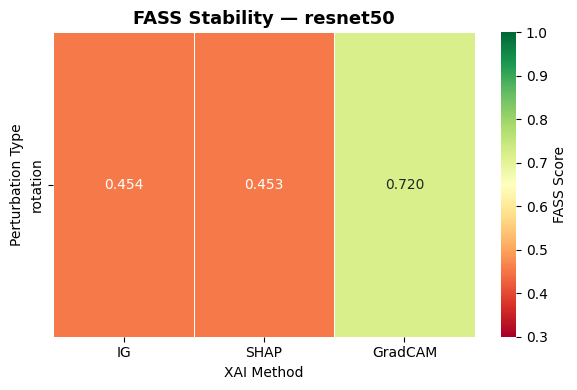

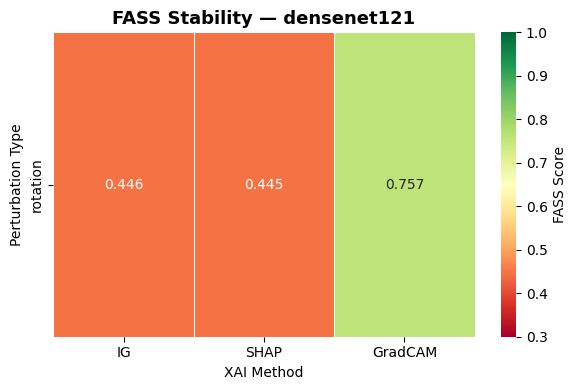

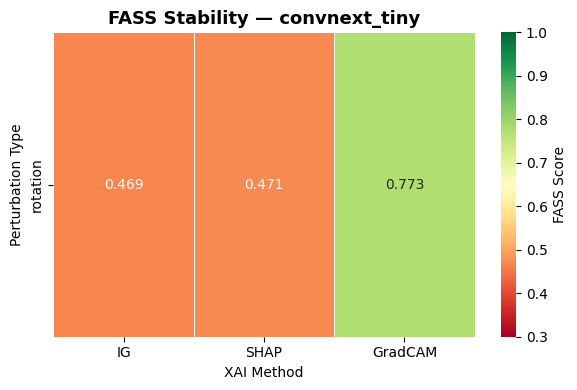

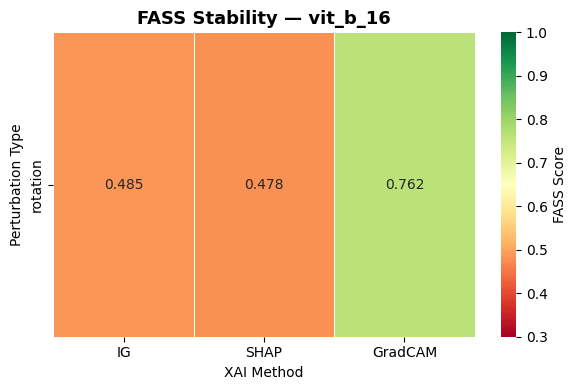

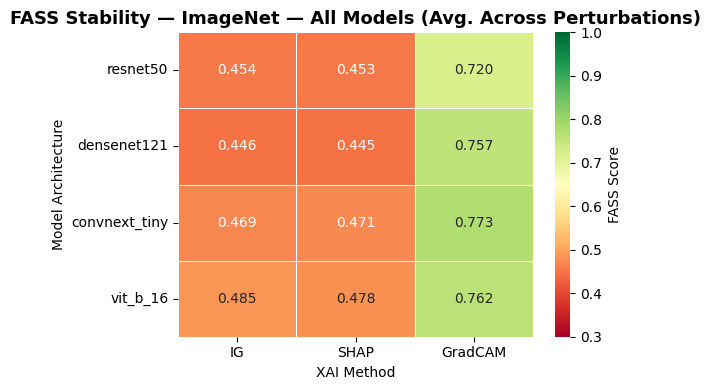

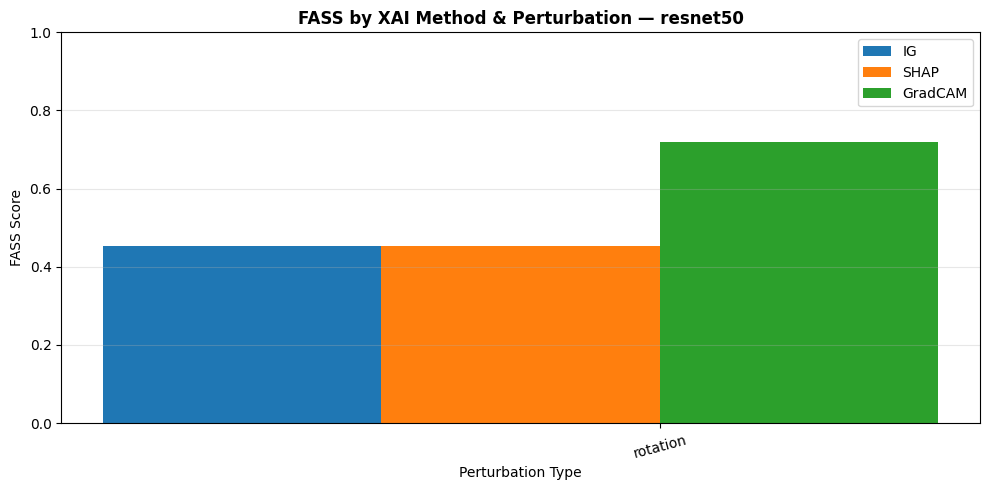

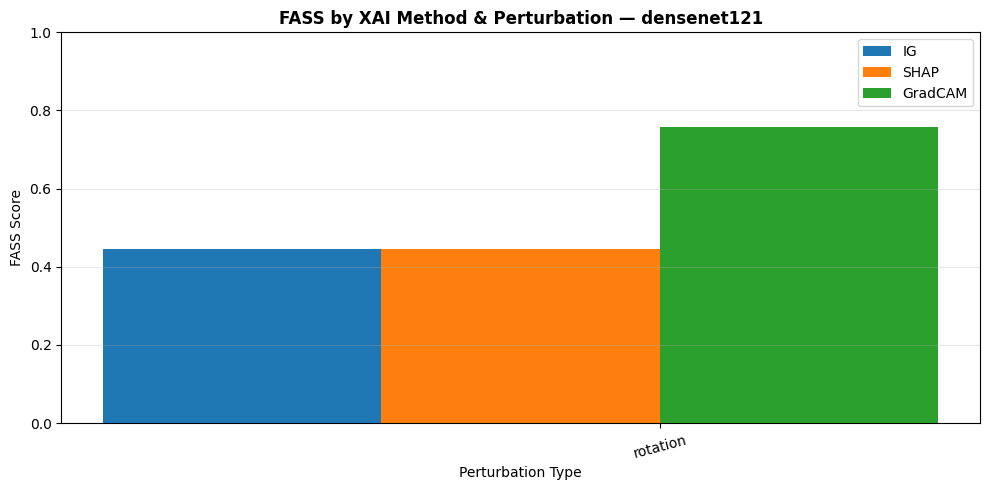

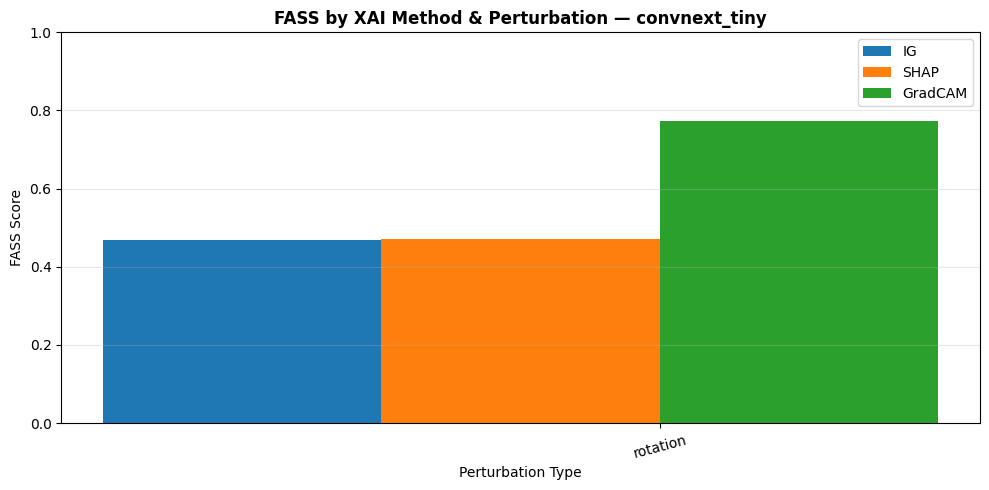

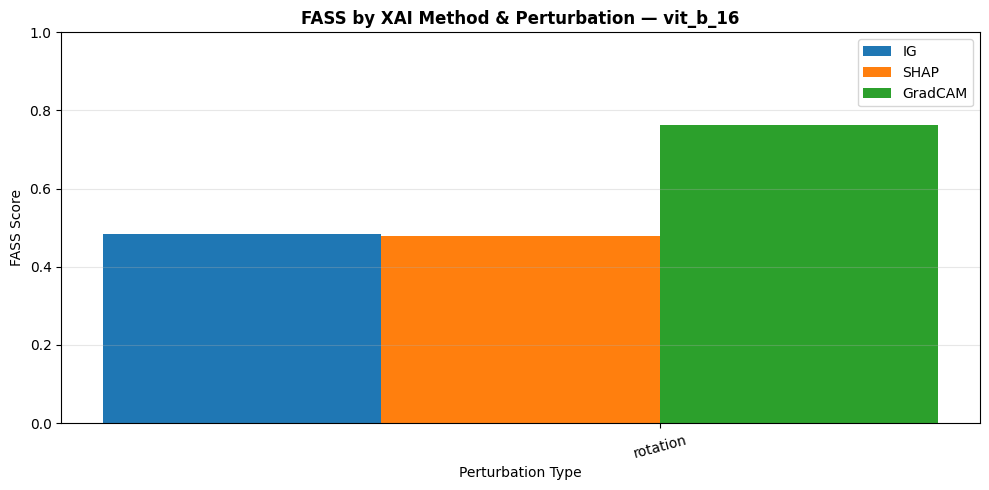

In [18]:
summary = load_all_results(RESULT_DIR)
if summary is not None:
    generate_latex_tables(summary)
    generate_grand_summary_latex(summary)
    plot_per_model_heatmaps(summary)
    plot_grand_heatmap(summary)
    plot_grouped_bar(summary)

In [27]:

"""
from captum.attr import IntegratedGradients, LayerGradCam, GradientShap
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings("ignore")

BRAIN_TUMOR_PATH = "/content/tumor2.jpg"
COCO_PEDESTRIAN_PATH = "/content/Self Driving Car Pedestrian Image 2.png"
SAVE_DIR = "/content/drive/MyDrive/results_coco/figures"
os.makedirs(SAVE_DIR, exist_ok=True)

torch.manual_seed(42)

norm_tf = transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])

MODEL_NAMES = ["resnet50", "densenet121", "convnext_tiny", "vit_b_16"]
DISPLAY_NAMES = ["ResNet-50", "DenseNet-121", "ConvNeXt-Tiny", "ViT-B/16"]
to_tensor = transforms.ToTensor()


# Same target layer mapping as run_benchmark
def get_target_layer(name, model):
    if name == "resnet50": return model.layer4[-1]
    elif name == "densenet121": return model.features[-1]
    elif name == "convnext_tiny": return model.features[-1]
    elif name == "vit_b_16": return model.encoder.layers[-1]

def load_img(path):
    img = Image.open(path).convert("RGB")
    img = TF.resize(img, (224, 224))
    orig = norm_tf(to_tensor(img)).unsqueeze(0).to(DEVICE)
    return img, orig

# Same perturbation logic as FASSCOCODataset.__getitem__

def perturb_single(pil_img, p_type):
    if p_type == "rotation":
        pert_pil = TF.rotate(pil_img, 15)
        p = norm_tf(to_tensor(pert_pil))
    return pert_pil, p.unsqueeze(0).to(DEVICE)

    elif p_type == "noise":
        actual_img_tensor = to_tensor(pil_img)
        random_noise = torch.randn_like(actual_img_tensor) * 0.01
        noisy = torch.clamp(actual_img_tensor + random_noise, 0, 5)
        p = norm_tf(noisy)
        pert_pil = transforms.ToPILImage()(noisy)


# Get IG + GradCAM + SHAP attributions for a single image
def get_attr(tensor, model, target_layer):
    tensor = tensor.requires_grad_(True)
    ig_fn = IntegratedGradients(model)
    gcam_fn = LayerGradCam(model, target_layer)
    gs_fn = GradientShap(model)
    with torch.no_grad():
        pred = torch.argmax(model(tensor), 1)
    ig_a = ig_fn.attribute(tensor, target=pred, internal_batch_size=8)
    gc_a = TF.resize(gcam_fn.attribute(tensor, target=pred), (224, 224))
    gs_a = gs_fn.attribute(tensor, target=pred, n_samples=5, baselines=torch.zeros_like(tensor))
    return pred.item(), ig_a.detach(), gc_a.detach(), gs_a.detach()

def to_heatmap(attr):
    h = attr.squeeze().cpu().abs()
    if h.dim() == 3: h = h.mean(0)
    cap = torch.quantile(h, 0.95)  # More aggressive — 95th percentile
    h = torch.clamp(h, max=cap)
    h = (h - h.min()) / (h.max() - h.min() + 1e-8)
    return h.numpy()

# Load models using existing prepare_models()
m_dict = prepare_models()

# ---------- Generate One Figure Per Domain ----------
def generate_figure(domain_name, img_path, save_prefix):
    pil_orig, t_orig = load_img(img_path)
    perturbation_list = [("rotation", "+15° Rotation")] #("noise", "Gaussian Noise (σ=0.01)")]

    # 7 columns: Original | GradCAM orig | GradCAM pert | IG orig | IG pert | SHAP orig | SHAP pert
    fig, axes = plt.subplots(8, 7, figsize=(30, 28))
    results = []
    row = 0

    for p_type, p_label in perturbation_list:
        pil_pert, t_pert = perturb_single(pil_orig, p_type)

        for mi, (mname, dname) in enumerate(zip(MODEL_NAMES, DISPLAY_NAMES)):
            print(f"  {domain_name} | {p_label} | {dname}...")

            model = m_dict[mname]
            model.to(DEVICE)
            target_layer = get_target_layer(mname, model)

            pred_o, ig_o, gc_o, gs_o = get_attr(t_orig, model, target_layer)
            pred_p, ig_p, gc_p, gs_p = get_attr(t_pert, model, target_layer)

            f_gc = calculate_fass(gc_o, gc_p).item()
            f_ig = calculate_fass(ig_o, ig_p).item()
            f_gs = calculate_fass(gs_o, gs_p).item()
            pred_match = pred_o == pred_p

            results.append(f"{dname} | {p_label} | Match: {pred_match} | GradCAM: {f_gc:.3f} | IG: {f_ig:.3f} | SHAP: {f_gs:.3f}")

            r = row + mi

            # Col 0: Original image with model name
            axes[r, 0].imshow(pil_orig)
            axes[r, 0].set_ylabel(dname, fontsize=12, fontweight='bold', rotation=90, labelpad=10)
            axes[r, 0].set_xticks([]); axes[r, 0].set_yticks([])

            # Col 1: GradCAM on original — keep overlay, looks good
            axes[r, 1].imshow(pil_orig)
            axes[r, 1].imshow(to_heatmap(gc_o), cmap='jet', alpha=0.5)
            axes[r, 1].axis('off')

            # Col 2: GradCAM on perturbed
            axes[r, 2].imshow(pil_pert)
            axes[r, 2].imshow(to_heatmap(gc_p), cmap='jet', alpha=0.5)
            gc_color = '#2ca02c' if f_gc >= 0.6 else '#ff7f0e' if f_gc >= 0.4 else '#d62728'
            axes[r, 2].set_xlabel(f'FASS: {f_gc:.3f}', fontsize=11, fontweight='bold', color=gc_color)
            axes[r, 2].set_xticks([]); axes[r, 2].set_yticks([])

            # Col 3: IG on original — pure heatmap, no image underneath
            axes[r, 3].imshow(to_heatmap(ig_o), cmap='jet', vmin=0, vmax=1)
            axes[r, 3].axis('off')

            # Col 4: IG on perturbed
            axes[r, 4].imshow(to_heatmap(ig_p), cmap='jet', vmin=0, vmax=1)
            ig_color = '#2ca02c' if f_ig >= 0.6 else '#ff7f0e' if f_ig >= 0.4 else '#d62728'
            axes[r, 4].set_xlabel(f'FASS: {f_ig:.3f}', fontsize=11, fontweight='bold', color=ig_color)
            axes[r, 4].set_xticks([]); axes[r, 4].set_yticks([])

            # Col 5: SHAP on original — pure heatmap, no image underneath
            axes[r, 5].imshow(to_heatmap(gs_o), cmap='jet', vmin=0, vmax=1)
            axes[r, 5].axis('off')

            # Col 6: SHAP on perturbed
            axes[r, 6].imshow(to_heatmap(gs_p), cmap='jet', vmin=0, vmax=1)
            gs_color = '#2ca02c' if f_gs >= 0.6 else '#ff7f0e' if f_gs >= 0.4 else '#d62728'
            axes[r, 6].set_xlabel(f'FASS: {f_gs:.3f}', fontsize=11, fontweight='bold', color=gs_color)
            axes[r, 6].set_xticks([]); axes[r, 6].set_yticks([])

            # Free GPU
            model.cpu()
            del ig_o, gc_o, gs_o, ig_p, gc_p, gs_p
            torch.cuda.empty_cache()

        if row == 0:
            axes[0, 0].set_title("Original", fontsize=11, fontweight='bold')
            axes[0, 1].set_title("GradCAM\n(original)", fontsize=11, fontweight='bold')
            axes[0, 2].set_title("GradCAM\n(perturbed)", fontsize=11, fontweight='bold')
            axes[0, 3].set_title("IG\n(original)", fontsize=11, fontweight='bold')
            axes[0, 4].set_title("IG\n(perturbed)", fontsize=11, fontweight='bold')
            axes[0, 5].set_title("SHAP\n(original)", fontsize=11, fontweight='bold')
            axes[0, 6].set_title("SHAP\n(perturbed)", fontsize=11, fontweight='bold')

        # Perturbation separator label
        fig.text(0.5, 1.0 - (row / 8.0) - 0.01, f"── {p_label} ──",
                fontsize=13, fontweight='bold', ha='center', va='bottom',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.9))

        row += 4

    fig.suptitle(f"Attribution Stability — {domain_name}",
                fontsize=16, fontweight='bold', y=1.01)
    plt.tight_layout()

    save_pdf = os.path.join(SAVE_DIR, f"{save_prefix}.pdf")
    save_png = os.path.join(SAVE_DIR, f"{save_prefix}.png")
    plt.savefig(save_pdf, dpi=300, bbox_inches='tight')
    plt.savefig(save_png, dpi=300, bbox_inches='tight')
    plt.show()

    print(f"\n{'='*70}")
    print(f"RESULTS — {domain_name}")
    print(f"{'='*70}")
    for r in results:
        print(r)
    print(f"Saved: {save_pdf}")
    return results

print("=" * 70)
print("FIGURE 1: Brain Tumor MRI")
print("=" * 70)
r1 = generate_figure("Brain Tumor MRI (Meningioma)", BRAIN_TUMOR_PATH, "fig1_brain_tumor")

print("\n" + "=" * 70)
print("FIGURE 2: Autonomous Driving")
print("=" * 70)
r2 = generate_figure("Autonomous Driving — Street Scene", COCO_PEDESTRIAN_PATH, "fig2_street_scene")
"""

'\nfrom captum.attr import IntegratedGradients, LayerGradCam, GradientShap\nimport matplotlib.pyplot as plt\nimport matplotlib.gridspec as gridspec\nimport warnings\nwarnings.filterwarnings("ignore")\n\nBRAIN_TUMOR_PATH = "/content/tumor2.jpg"\nCOCO_PEDESTRIAN_PATH = "/content/Self Driving Car Pedestrian Image 2.png"\nSAVE_DIR = "/content/drive/MyDrive/results_coco/figures"\nos.makedirs(SAVE_DIR, exist_ok=True)\n\ntorch.manual_seed(42)\n\nnorm_tf = transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])\n\nMODEL_NAMES = ["resnet50", "densenet121", "convnext_tiny", "vit_b_16"]\nDISPLAY_NAMES = ["ResNet-50", "DenseNet-121", "ConvNeXt-Tiny", "ViT-B/16"]\nto_tensor = transforms.ToTensor()\n\n\n# Same target layer mapping as run_benchmark\ndef get_target_layer(name, model):\n    if name == "resnet50": return model.layer4[-1]\n    elif name == "densenet121": return model.features[-1]\n    elif name == "convnext_tiny": return model.features[-1]\n    elif name == "vit_b_16": return 